# Polynomer i blindsonen
Hvordan kan matematisk likeverdige beskrivelser av det samme polynomrommet gi svært forskjellige numeriske resultater?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def chebyshev_recursive(n, x):
    """Beregn T_n(x) direkte fra den rekursive definisjonen."""
    if n < 0:
        raise ValueError("n må være et ikke-negativt heltall")
    if n == 0:
        return 1 + 0*x       # TODO: forklar hvorfor 0*x er nyttig for arrays
    if n == 1:
        return x
    return (2*x*chebyshev_recursive(n-1, x)
            - chebyshev_recursive(n-2, x))


for n in range(5):
    print(f"T_{n}(0.3) = {chebyshev_recursive(n, 0.3): .8f}")

T_0(0.3) =  1.00000000
T_1(0.3) =  0.30000000
T_2(0.3) = -0.82000000
T_3(0.3) = -0.79200000
T_4(0.3) =  0.34480000


$T_0 = 1$

$T_1 = x$

$T_2 = 2x*x-1 =2x^2-1$

$T_3 = 2x(2x^2-1)-x =4x^3-3x$

$T_4 = 2x(4x^3-3x)-(2x^2-1) =8x^4-8x^2+1$

In [ ]:
import numpy as np

def chebyshev_table(x, n):
    """Returner ean tabell med T_0(x), ..., T_n(x) som kolonner."""
    x = np.asarray(x, dtype=float)
    # En rad hører til én x-verdi. Den siste aksen reserveres for
    # polynomnummeret k: kolonne k inneholder T_k(x).
    table = np.empty(x.shape + (n+1,), dtype=float)
    table[..., 0] = 1.0
    if n >= 1:
        table[..., 1] = x
    # Tabellen tar vare på tidligere resultater. Derfor kan hver ny kolonne
    # bygges fra de to foregående uten å beregne dem på nytt.
    for k in range(1, n):
        table[..., k+1] = 2*x*table[..., k] - table[..., k-1]
    return table


x_test = np.array([-1.0, -0.25, 0.0, 0.4, 1.0])
print(chebyshev_table(x_test, 4))

[[ 1.      -1.       1.      -1.       1.     ]
 [ 1.      -0.25    -0.875    0.6875   0.53125]
 [ 1.       0.      -1.      -0.       1.     ]
 [ 1.       0.4     -0.68    -0.944   -0.0752 ]
 [ 1.       1.       1.       1.       1.     ]]


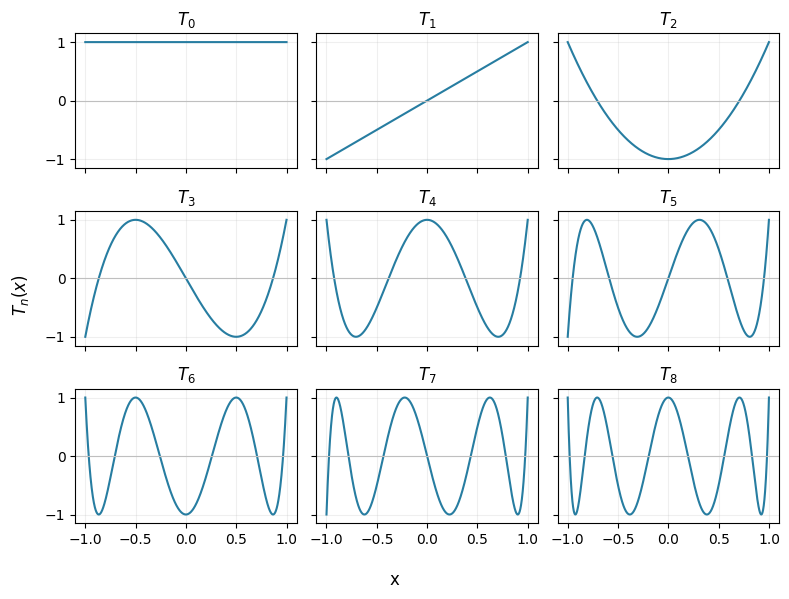

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_plot = np.linspace(-1.0, 1.0, 1200)
# Tabellen gjør at vi beregner alle ni kurvene i ett kall. T_plot[:, n]
# betyr: alle x-rader, men bare kolonnen som hører til T_n.
T_plot = chebyshev_table(x_plot, 8)

plt.close("all")
fig, axes = plt.subplots(3, 3, figsize=(8, 6), sharex=True, sharey=True)
for n, ax in enumerate(axes.ravel()):
    ax.plot(x_plot, T_plot[:, n], color="#277da1")
    ax.axhline(0, color="0.75", linewidth=0.8)
    ax.set_title(f"$T_{n}$")
    ax.grid(alpha=0.2)
    ax.set_ylim(-1.15, 1.15)
fig.supxlabel("x")
fig.supylabel("$T_n(x)$")
plt.tight_layout()
plt.show()

1. Alle T_n får verdien 1 i endepunktet sitt. For n som partall (og null) starter den i 1, mens for oddetall starter den i -1. De har hele verdiemengden mellom [-1,1].
2. Alle T_n får n antall nullpunkter. Vi ser at perioden også blir raskere når n øker. Hvis n er et partall er T_n symmetrisk om y-aksen (x = 0). hvis n er oddetall er det antisymmetrisk om origo, f(-x) = -f(x). Dette vil si at hvis (x,y) er på grafen, så er også (-x, -y) på grafen
3. For T_2 får vi:

$T_2(x) = 2x*T_1 - 1$

$T_2(x) = 2x^2 - 1$
    
$T_2(x) = 2(x^2-\frac{1}{2})$.

Vi kan se at bunnpunktet blir når x = 0, og at den har toppunkt i x = +-1

In [ ]:
# Hver kolonne skal inneholde monomialkoeffisientene til ett T_k.
# Rekkefølgen på radene er 1, x, x^2, x^3, x^4.
Q = np.full((5, 5), np.nan)
# Kolonne k er koeffisientlisten til T_k. Rangtesten undersøker om de fem
# listene, og dermed de fem polynomene, er lineært uavhengige.
Q[:, 0] = [1, 0, 0, 0, 0]  # T_0
Q[:, 1] = [0, 1, 0, 0, 0]  # T_1
Q[:, 2] = [-1, 0, 2, 0, 0]  # T_2
Q[:, 3] = [0, -3, 0, 4, 0]  # T_3
Q[:, 4] = [1, 0, -8, 0, 8]  # T_4

if np.isnan(Q).any():
    print("Fyll inn de tre siste kolonnene før rangtesten.")
else:
    print("Rang:", np.linalg.matrix_rank(Q))
    print("Diagonal:", np.diag(Q))
    print("Det:", np.linalg.det(Q))

Rang: 5
Diagonal: [1. 1. 2. 4. 8.]
Det: 63.99999999999998


T_0-T_4 danner en basis for P_4. Determinanten er non-zero, dette gjør at den har full kolonne rang. Dette forteller oss at alle kolonnene i Q er liniært uavhenging. Q vil alltid danne en triagulær form, fordi når vi øker n får vi en ny unik x^n ledd i basisen, P_n.

## Del 1 Reverse engineering fra polynomverdier

In [ ]:
def monomial_matrix(points, n):
    """Avlesningsmatrise for basisen (1, x, ..., x^n)."""
    points = np.asarray(points, dtype=float)
    powers = np.arange(n+1)
    # points[:, None] # lager en punktkolonne, og powers[None, :] lager en
    # potensrad. NumPy kombinerer dem til alle x_i**j samtidig.
    # TODO: Erstatt neste linje med uttrykket points[:, None] opphøyd i
    # powers[None, :]. Kontroller resultatet mot minieksemplene over.
    return points[:, None]**powers[None, :]


def chebyshev_matrix(points, n):
    """Avlesningsmatrise for basisen (T_0, ..., T_n)."""
    # chebyshev_table har allerede riktig design: rad i = punkt x_i og
    # kolonne k = T_k evaluert i alle punktene.
    return chebyshev_table(points, n)


points_small = np.array([-1.0, -1/3, 1/3, 1.0])
M_small = monomial_matrix(points_small, 3)
C_small = chebyshev_matrix(points_small, 3)

print("Monomialbasis:\n", M_small)
print("\nChebyshev-basis:\n", C_small)
print("\nRanger:", np.linalg.matrix_rank(M_small),
      np.linalg.matrix_rank(C_small))

Monomialbasis:
 [[ 1.         -1.          1.         -1.        ]
 [ 1.         -0.33333333  0.11111111 -0.03703704]
 [ 1.          0.33333333  0.11111111  0.03703704]
 [ 1.          1.          1.          1.        ]]

Chebyshev-basis:
 [[ 1.         -1.          1.         -1.        ]
 [ 1.         -0.33333333 -0.77777778  0.85185185]
 [ 1.          0.33333333 -0.77777778 -0.85185185]
 [ 1.          1.          1.          1.        ]]

Ranger: 4 4


1. P_3 er definert for alle polynomer med form: $a_0 + a_1x +a_2x^2 +a_3x^3$. Det vil ha verdimengde i hele $\mathbb{R^4}$, fordi vi regner ut 4 verdier P(x)_0, ..., P_3. Et element i dette rommet vil gi de 4 reele verdiene vi får nå vi regner ut P_0, ..., P_3
2. M_small inneholder verdier tilhørende basis i punktet x . Hvis M_small = (1, 2, 4, 8) har vi x = 2, (1, 2, 2^2, 2^3). Da får vi utregning for polynomet med M_small sine verdier i punketet x:

    $a_0 + a_1x +a_2x^2 +a_3x^3$.


    Dette er det samme som E(p(2), som tar et polynom og regner verdien i et punkt.
   
   For E(p(2):

   p(2) = M_small @ a for raden x = 2

   (1, 2, 4, 8) (a_0, a_1, a_2, a_3)^T = a_0 + 2a_1 + 4a_2 + 8a_3. Her er a_i koeffientene.

3. Fordi de har forskjellig basiser. C_small er verdiene av chebyshev basisfunksjonene, mens c inneholder koeffisitenene til p i chebyshev basis. C_small er hvor vi skal, mens c inneholder hvor lange "stegene" er. Men vi ender opp på samme plass. Vi justerer C_small slik at vi ender opp på samme sted når vi endrer basis.

4. At begge matrissene har rang 4 betyr at de har trivielt nullrom, dette betyr at bare nullvektoren kan gi løsning lik nullvektoren. Hvis de hadde samme fire avlesninger ville differansen mellom koeffisientene ligget i nullrommet. Dermed må de være identiske fordi nullrommet kun inneoholder nullvektoren. Dermed kan en avlesning i P_3 bare gi et polynom.

5. De tilhører to forksjellige basiser, så polynomene er ikke nødvendigvis forskjellige.

    p(x) = c_0T_0(x) + c_1T_1(x) +c_2T_2(x) c_3T_3(x)

    p(x) = a_0 + a_1x + a_2x^2 + a_3x^3

    Dette kan kontrolleres hvis M_small @ a = C_small @ c, for hver verdi. Dermed beskriver a og c det samme polynomet

In [ ]:
from numpy.polynomial import polynomial as poly
from numpy.polynomial import chebyshev as cheb


monomial_true = np.array([1.0, -2.0, 0.5, 1.0])
# Dette er de eneste dataene de to lineære systemene får.
measurements_small = poly.polyval(points_small, monomial_true)

# Begge systemene har formen «avlesningsmatrise @ koordinater = data».
# solve returnerer koordinatene; hvilken basis de tilhører bestemmes av
# matrisen på venstre side.
monomial_recovered = np.linalg.solve(M_small, measurements_small)
chebyshev_recovered = np.linalg.solve(C_small, measurements_small)

print("Avlesninger:", measurements_small)
print("Monomialkoordinater:", monomial_recovered)
print("Chebyshev-koordinater:", chebyshev_recovered)

x_dense = np.linspace(-1, 1, 1001)
p_reference = poly.polyval(x_dense, monomial_true)
p_from_monomials = poly.polyval(x_dense, monomial_recovered)
p_from_chebyshev = cheb.chebval(x_dense, chebyshev_recovered)

print("Største forskjell, monomial:",
      np.max(np.abs(p_from_monomials-p_reference)))
print("Største forskjell, Chebyshev:",
      np.max(np.abs(p_from_chebyshev-p_reference)))

Avlesninger: [2.5        1.68518519 0.42592593 0.5       ]
Monomialkoordinater: [ 1.  -2.   0.5  1. ]
Chebyshev-koordinater: [ 1.25 -1.25  0.25  0.25]
Største forskjell, monomial: 4.440892098500626e-16
Største forskjell, Chebyshev: 4.440892098500626e-16


Utregniner:

Monomial: 1-2x+0.5x^2+x^3

Chebyshev: 1.25(1) + -1.25(x) + 0.25(2x^2-1) + 0.25(4x^3-3x) = 1-2x+0.5x^2+x^3


In [ ]:
# Forsøk A: Fjern den siste avlesningen.
points_three = points_small[:-1]
M_three = monomial_matrix(points_three, 3)

# Forsøk B: Bruk fire plasser, men les av samme punkt to ganger.
points_repeated = np.array([-1.0, -1/3, 1/3, 1/3])
M_repeated = monomial_matrix(points_repeated, 3)

print("Form og rang med tre avlesninger:",
      M_three.shape, np.linalg.matrix_rank(M_three))
print("Form og rang med gjentatt punkt:",
      M_repeated.shape, np.linalg.matrix_rank(M_repeated))

Form og rang med tre avlesninger: (3, 4) 3
Form og rang med gjentatt punkt: (4, 4) 3


Største avvik fra polyfromroots: 0.0
Koeffisienter til z: [-0.11111111 -0.11111111  1.          1.        ]
Avlesninger av p:        [2.5        1.68518519 0.42592593]
Avlesninger av p+alpha*z: [2.5        1.68518519 0.42592593]
Forskjell i avlesningene: [ 0.00000000e+00  0.00000000e+00 -1.11022302e-16]


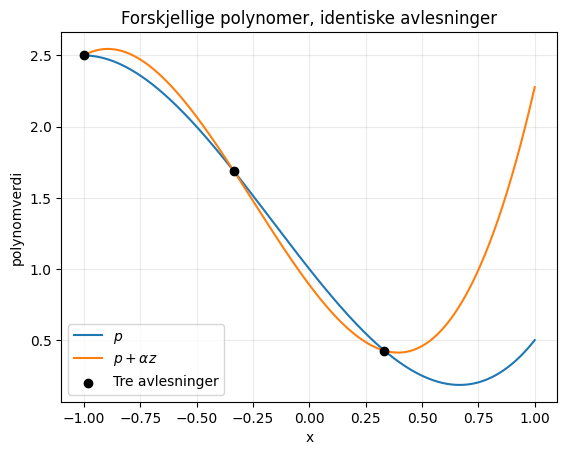

In [ ]:
# TODO: Utvid produktet du fant, og skriv inn de fire koeffisientene i
# rekkefølgen 1, x, x^2, x^3. NaN-verdiene skal erstattes.
invisible_coefficients = np.full(4, [-1/9,-1/9,1,1])
if np.isnan(invisible_coefficients).any():
    raise ValueError("Fyll inn koeffisientene til z før du går videre")

# Biblioteket brukes her bare som en uavhengig kontroll av håndregningen.
coefficients_check = poly.polyfromroots(points_three)
print("Største avvik fra polyfromroots:",
      np.max(np.abs(invisible_coefficients-coefficients_check)))

# Velg selv en synlig skaleringsfaktor.
alpha = 1.0
second_polynomial = monomial_true + alpha*invisible_coefficients

# De to polynomene er forskjellige, men z er null i alle tre punktene.
first_values = poly.polyval(points_three, monomial_true)
second_values = poly.polyval(points_three, second_polynomial)

print("Koeffisienter til z:", invisible_coefficients)
print("Avlesninger av p:       ", first_values)
print("Avlesninger av p+alpha*z:", second_values)
print("Forskjell i avlesningene:", second_values-first_values)

plt.close("all")
plt.plot(x_dense, poly.polyval(x_dense, monomial_true), label="$p$")
plt.plot(x_dense, poly.polyval(x_dense, second_polynomial),
         label="$p+\\alpha z$")
plt.scatter(points_three, first_values, color="black", zorder=3,
            label="Tre avlesninger")
plt.xlabel("x")
plt.ylabel("polynomverdi")
plt.title("Forskjellige polynomer, identiske avlesninger")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

1. z(x) = -1/9-x/9+x^2+x^3

E(z) = (z(-1/3), z(1/3), z(-1)) = (0, 0, 0)

z(-1/3) = 0

z(1/3) = 0

z(-1) = 0

z(1) = 16/9

z er ikke nullpolynomet i P_3, men E(z) er likevel nullvektoren i R_3, fordi E bare bruker 3 kordinater av de fire koeffisientene. Dimemsjonen av P_3 er større en antall avlesningspunkter, så det må være en nullforskjellig vektor som sendes til null.

2. E(p+az) = E(p) +aE(z)

    → E(p+az) = E(p) + a*(0,..,0)^T, E(z) er nullvektor så den sender alt til null
    
    → E(p+az) = E(p) + (0,..,0)^T
    
    → E(p+az) = E(p)

    Her kan vi set at uansett hva vi velger for a blir det borte, fordi e(z) er en nullvektor. Dermed blir det likt de punktene vi har for p     


3. Matrisen M har form (m x n+1), hvert punkt gir en uavhening betingelse får vi da at rang(M) = m. Hver rad i M er LU, så den har full radrang. dim(ker M) = n+1 - rang(M) = n + 1 - m, detter er større enn null fordi m < n + 1. Så lenge vi har færre punkter enn dimensjoer til polynomrommet (m < n+1), kan evalueringen aldri være 1-1 (injektiv) på P_n.

4. dim(Ker E) + rang(E) = n + 1

   Vi skal finne dimensjonen til nullrommet:

   dim(Ker E) = n + 1 - m.

   Dette gir n + 1 - m uavhenginge rettninger som utspent av z_1, ...m z_i som vil sendes til null av E, E(z_i) = 0. Dette ble visst tidligere for E(z) der (z(-1/3), z(1/3), z(-1)) ble sendt til null.

5. Hvis et punkt ble gjentatt har du egentlig et den samme informasjonen to ganger (det er LA, det kan uttrykkes med informasjonen vi har fra de andre punktene). Vi har rang(E) = 2, fordi en rad er LA. Dette gir da:

→ dim(Ker E) = 4 - rang(E) = 4 - 2 = 2. Vi får dobbelt så stort nullrom, vi har nå to rettninger som sendes til nullvektoren.

Dette er det samme som om vi ikke hadde punktet i det hele tatt:

Form og rang med tre avlesninger: (3, 4) 3

Form og rang med gjentatt punkt: (4, 4) 3




## Del 2 Hold punktene fast og bytt basis

In [ ]:
def chebyshev_points(n):
    """Returner n+1 cosinusfordelte punkter i intervallet [-1,1]."""
    # P_n har dimensjon n+1, så vi bruker n+1 forskjellige avlesninger.
    k = np.arange(n+1)
    return np.cos((2*k+1)*np.pi/(2*(n+1)))


def reference_coordinates(n):
    """Moderate, deterministiske koordinater i Chebyshev-basis."""
    # En fast formel gir samme referansepolynom hver gang forsøket gjentas.
    # Avtagende koeffisienter hindrer at vi bygger inn store tall med vilje.
    k = np.arange(n+1)
    return (-1.0)**k/(k+1.0)**2


def max_grid_error(values, reference):
    # Maksimum på et tett rutenett er en numerisk måling, ikke et bevis på
    # maksimum over alle reelle x i intervallet.
    return float(np.max(np.abs(values-reference)))

In [ ]:
def compare_bases(n, grid_size=2001):
    # Det samme polynomet leses av i de samme punktene for begge basiser.
    points = chebyshev_points(n)
    true_chebyshev = reference_coordinates(n)
    measurements = cheb.chebval(points, true_chebyshev)

    # Bare koordinatsystemet endres mellom de to lineære systemene.
    M = monomial_matrix(points, n)
    C = chebyshev_matrix(points, n)

    # Reverse engineering i to basiser: solve finner koeffisientene som gir
    # de oppgitte avlesningene. Svarvektorene kan ikke sammenlignes ledd for
    # ledd fordi basisene er ulike.
    recovered_monomial = np.linalg.solve(M, measurements)
    recovered_chebyshev = np.linalg.solve(C, measurements)

    # Det tette rutenettet gir ingen nye data til systemet. Det brukes bare
    # til å sammenligne de to ferdige polynomene mellom avlesningspunktene.
    grid = np.linspace(-1.0, 1.0, grid_size)
    reference = cheb.chebval(grid, true_chebyshev)
    from_monomials = poly.polyval(grid, recovered_monomial)
    from_chebyshev = cheb.chebval(grid, recovered_chebyshev)

    return {
        "n": n,
        "points": points,
        "measurements": measurements,
        "grid": grid,
        "reference": reference,
        "monomial_values": from_monomials,
        "chebyshev_values": from_chebyshev,
        "monomial_coordinates": recovered_monomial,
        "chebyshev_coordinates": recovered_chebyshev,
        "monomial_error": max_grid_error(from_monomials, reference),
        "chebyshev_error": max_grid_error(from_chebyshev, reference),
    }


basis_data = compare_bases(30)
print("Grad:", basis_data["n"])
print("Største |monomialkoordinat|:",
      np.max(np.abs(basis_data["monomial_coordinates"])))
print("Største |Chebyshev-koordinat|:",
      np.max(np.abs(basis_data["chebyshev_coordinates"])))
print("Maksfeil med monomialbasis:", basis_data["monomial_error"])
print("Maksfeil med Chebyshev-basis:", basis_data["chebyshev_error"])

Grad: 30
Største |monomialkoordinat|: 32003919.49921413
Største |Chebyshev-koordinat|: 0.9999999999999997
Maksfeil med monomialbasis: 1.9591267053087336e-08
Maksfeil med Chebyshev-basis: 1.1102230246251565e-15


In [ ]:
mono_err_array = np.abs(basis_data["monomial_values"] - basis_data["reference"])
cheb_err_array = np.abs(basis_data["chebyshev_values"] - basis_data["reference"])

x_mono_worst = basis_data["grid"][np.argmax(mono_err_array)]
x_cheb_worst = basis_data["grid"][np.argmax(cheb_err_array)]

print(f"Monomialbasis:  x = {x_mono_worst:.4f}")
print(f"Chebyshev-basis: x = {x_cheb_worst:.4f}")

Monomialbasis:  x = -0.5070
Chebyshev-basis: x = -0.9650


1. `measurements` ble laget en gang, og det ble brukt det samme i line 14, 15, der arg 2 er på høyresiden. Dette sier at begge systemene skal ha samme løsning.
2. `feil_m = 1.959e-08` og `feil_c = 1.110e-15`, det er 7 tier potenser i forskjell.
3. Feilen ligger rundt -0.5 for monomial basis og rundt -0.96 for chebyshev basis.
4. Vi beholder heletiden det samme polynomrommet, her med grad 30. Det er også det samme referansepolynomet, siden true_chebyshev brukes av measurments. Avlesningspunktene er også de samme fordi de begge referer til chebyshev_points(n). Avlesningsverdiene er de samme fordi measurments brukes som høyreside i begge systemene. Den eneste endringen er hvilken basis vi er i, i den ene er det monomial og for den andre er det chebyshev
5. Begge er mattematisk riktig, så feilen kommer fra flyttall pressision. Størrelses feilen i mellom feilene er et biprodukt melllom dette, skulle hvert 0 fordi begge skulle hvert 0. Men selve størrelsen til hver feil er basert på kondisjontallet til M og C.

In [ ]:
n = 30
points = chebyshev_points(n)
true_chebyshev = reference_coordinates(n)
measurements = cheb.chebval(points, true_chebyshev)

rng = np.random.default_rng(2026)
# Fast startverdi gjør forsøket reproduserbart: alle får nøyaktig samme
# forstyrrelse når cellen kjøres på nytt.
measurement_noise = 1e-10*rng.standard_normal(n+1)

M = monomial_matrix(points, n)
C = chebyshev_matrix(points, n)

a_before = np.linalg.solve(M, measurements)
a_after = np.linalg.solve(M, measurements+measurement_noise)
c_before = np.linalg.solve(C, measurements)
c_after = np.linalg.solve(C, measurements+measurement_noise)

# Normen samler endringene i hele koordinatvektoren til ett tall. Vi
# sammenligner før og etter innen samme basis, ikke koeffisienter på tvers.
print("Største endring i avlesning:", np.max(np.abs(measurement_noise)))
print("Endring i monomialkoordinater:", np.linalg.norm(a_after-a_before))
print("Endring i Chebyshev-koordinater:", np.linalg.norm(c_after-c_before))

Største endring i avlesning: 1.8963263495990658e-10
Endring i monomialkoordinater: 0.7437187278736606
Endring i Chebyshev-koordinater: 1.144178592765297e-10


1. Endringen i selve dataen var measurement_noise, på rundt 10^-10.
2. I monomial ble det endring på < 0.75, mens i chebyshev var det rundt 10^-10. Den lille data endringen hadde stor effekt på monomialkoordinatene, mens den var svært liten, samme størrelses orden som selve feilen.
3. Mm, monomial basis forstørret feilen mest.

## Del 3 Hold basisen fast og flytt punktene

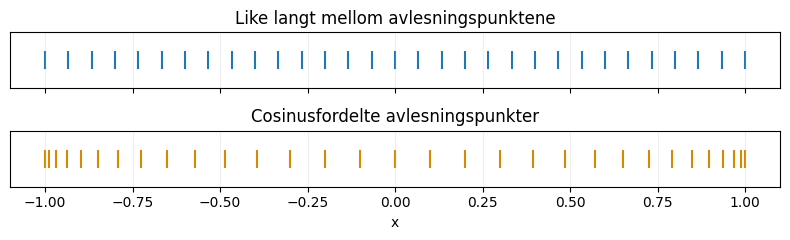

In [ ]:
n = 30
equal_points = np.linspace(-1.0, 1.0, n+1)
cheb_points = chebyshev_points(n)

# Punktene tegnes på hver sin tallinje før løsing. Figuren kontrollerer den
# variabelen vi skal endre: punktplasseringen.
plt.close("all")
fig, axes = plt.subplots(2, 1, figsize=(8, 2.5), sharex=True)
axes[0].scatter(equal_points, np.zeros_like(equal_points), marker="|", s=180)
axes[0].set_title("Like langt mellom avlesningspunktene")
axes[1].scatter(cheb_points, np.zeros_like(cheb_points), marker="|", s=180,
                color="#d98900")
axes[1].set_title("Cosinusfordelte avlesningspunkter")
for ax in axes:
    ax.set_yticks([])
    ax.grid(axis="x", alpha=0.2)
axes[1].set_xlabel("x")
plt.tight_layout()
plt.show()

Vi vil forvente at flere avlesningspunkter er bedre for å motvirke forstyrelser. Siden det er nær rundt -1, 1 så ville cosinusfordelte avlesningspunkter fungert bedre, fordi chebyshev-polynomene (cosinus liknende) er samlet rundt +-1.

In [ ]:
def point_placement_experiment(n, points, noise_size=1e-10,
                               grid_size=5001):
    # Lag de nøyaktige avlesningene fra ett fast referansepolynom.
    true_coordinates = reference_coordinates(n)
    measurements = cheb.chebval(points, true_coordinates)
    # Det samme fortegnsmønsteret brukes uansett hvor punktene ligger.
    noise = noise_size*(-1.0)**np.arange(n+1)

    # Reverse engineering: Finn koeffisientene til polynomet som passer til
    # de litt forstyrrede avlesningene.
    C = chebyshev_matrix(points, n)
    recovered = np.linalg.solve(C, measurements+noise)

    # Sammenlign med referansepolynomet også mellom avlesningspunktene. Det
    # tette rutenettet påvirker ikke løsningen; det fungerer som måleinstrument.
    grid = np.linspace(-1.0, 1.0, grid_size)
    reference = cheb.chebval(grid, true_coordinates)
    perturbed = cheb.chebval(grid, recovered)
    error = perturbed-reference

    return {
        "n": n,
        "points": points,
        "noise": noise,
        "grid": grid,
        "error": error,
        "max_data_error": float(np.max(np.abs(noise))),
        "max_curve_error": float(np.max(np.abs(error))),
    }


equal_data = point_placement_experiment(
    n, equal_points, noise_size=1e-10
)
cheb_data = point_placement_experiment(
    n, cheb_points, noise_size=1e-10
)

for name, data in [("Jevne punkter", equal_data),
                   ("Cosinusfordelte punkter", cheb_data)]:
    amplification = data["max_curve_error"]/data["max_data_error"]
    print(f"{name:27s}",
          f"feil i avlesning={data['max_data_error']:.3e}",
          f"kurvefeil={data['max_curve_error']:.3e}",
          f"forsterkning={amplification:.3e}")

Jevne punkter               feil i avlesning=1.000e-10 kurvefeil=6.601e-04 forsterkning=6.601e+06
Cosinusfordelte punkter     feil i avlesning=1.000e-10 kurvefeil=3.149e-10 forsterkning=3.149e+00


Feil i avlesning er lik, mens kurvefeil er  2 * 10^6 minde for cosinusfordelte punkter. De jevne punktene har en forsterkning som er ca 2 * 10^6 større enn de cosinusfordelte. Denne forskjellen kan ikke skyldes basis fordi begge bruker chebyshev matrix, det bruker bare en basis. Feil i avlesning er lik, altså feilen i inndataen er lik.

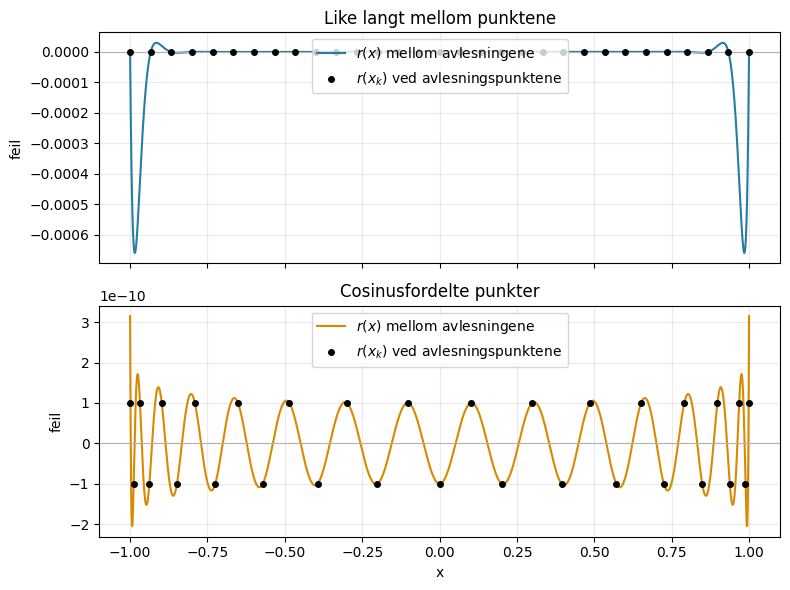

In [ ]:
plt.close("all")
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

for ax, title, data, color in [
    (axes[0], "Like langt mellom punktene", equal_data, "#277da1"),
    (axes[1], "Cosinusfordelte punkter", cheb_data, "#d98900"),
]:
    ax.plot(data["grid"], data["error"], color=color,
            label="$r(x)$ mellom avlesningene")
    ax.scatter(data["points"], data["noise"], color="black", s=16,
               zorder=3, label="$r(x_k)$ ved avlesningspunktene")
    ax.axhline(0, color="0.7", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("feil")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper center")

axes[1].set_xlabel("x")
plt.tight_layout()
plt.show()

1. For like fordelte punkter er feilen ved $r(x_k)$ tilnærmet 0, mens for cosniusfordelte er de +-1 i avlesningspunktene. For like lang mellom punktene har det en maksinums feil på ($|-0.0006|$), og for cosinus er det en maksfeil på over 3.
2. Det blir størst $r(x_k)$ for den jevne rett før endepunktene. Her er det få avlesninger.
3. Det blir størst $r(x_k)$ for cosinus i endepunktene, her er det mange avlesnignspunkter.
4. Både r og z viser at oppførsel i avlesnignspunkter kan variere i fra hvordan den underliggende funksjonenen faktisk er. Vi ser bare punktverdiene, ikke hva so skjer mellom dem.

   Forskjellen er hvorfor de oppstår. z er en produkt av rang-nullitet-theoremet. fordi m < n +1, så fantes det $n+1-m$ ikke null polynom som blir en nullvektor. r er et produkt av støy som blir introdusert, dette er en feilrespons for et entydingsystem. Dersom det ikke var noe støy ville r=0


## Finale: Beregn det samme polynomet på tre måter

In [ ]:
n = 50
x0 = 0.99

cheb_coordinates = np.zeros(n+1)
# Denne koordinatvektoren betyr 0*T_0 + ... + 1*T_50.
cheb_coordinates[n] = 1.0
# Konverteringen endrer koordinatene, ikke polynomet. Etterpå evalueres det
# samme matematiske objekt med to forskjellige representasjoner.
monomial_coordinates = cheb.cheb2poly(cheb_coordinates)

value_monomial = poly.polyval(x0, monomial_coordinates)
value_chebyshev = cheb.chebval(x0, cheb_coordinates)
value_reference = np.cos(n*np.arccos(x0))

print("Største monomialkoeffisient:",
      np.max(np.abs(monomial_coordinates)))
print("Monomialevaluering:   ", value_monomial)
print("Chebyshev-evaluering: ", value_chebyshev)
print("Cosinusreferanse:     ", value_reference)
print("Feil, monomial:       ", abs(value_monomial-value_reference))
print("Feil, Chebyshev:      ", abs(value_chebyshev-value_reference))

Største monomialkoeffisient: 1.2874559606751232e+18
Monomialevaluering:    -31.596144407541345
Chebyshev-evaluering:  0.7011491981769309
Cosinusreferanse:      0.7011491981769286
Feil, monomial:        32.297293605718274
Feil, Chebyshev:       2.3314683517128287e-15


Rangering:
1. cosinus representasjon: rent matematisk enkleste tilnærming
2. Chebyshev: Unngår mange opperasjoner, hvert del resultat holder seg mellom [-1, 1] unngår store størrelses forskjell
3. monomialkoefissienter: får sum av mange ledd, kan ha stor størrelses forskjell x^50 vs x^1.

In [ ]:
print(f"{'grad':>5} {'største koeff.':>18} "
      f"{'feil monomial':>18} {'feil Chebyshev':>18}")
print("-"*63)

for n_test in [10, 20, 30, 40, 50]:
    c = np.zeros(n_test+1)
    c[n_test] = 1.0
    a = cheb.cheb2poly(c)
    reference = np.cos(n_test*np.arccos(x0))
    monomial_value = poly.polyval(x0, a)
    chebyshev_value = cheb.chebval(x0, c)
    print(f"{n_test:5d} {np.max(np.abs(a)):18.4e} "
          f"{abs(monomial_value-reference):18.4e} "
          f"{abs(chebyshev_value-reference):18.4e}")

 grad     største koeff.      feil monomial     feil Chebyshev
---------------------------------------------------------------
   10         1.2800e+03         4.8322e-14         1.8596e-15
   11         2.8160e+03         2.7894e-14         2.2152e-15
   20         6.5536e+06         3.6029e-10         0.0000e+00
   25         4.6694e+08         4.8156e-09         8.8818e-16
   30         3.6176e+10         8.0878e-07         1.7764e-15
   35         2.7893e+12         2.3126e-05         2.4702e-15
   40         2.1236e+14         2.6183e-04         1.1102e-15
   45         1.6169e+16         8.4735e-01         1.7764e-15
   50         1.2875e+18         3.2297e+01         2.3315e-15


1. Størrelsen på et polynom på intervallet er størrste funksjonverdi den kan ta på intervallet, (max(|f(x)|), x ∈ [-1, 1]). Mens koeffisientne er en egenskap av hvilken basis som blir brukt.
2. Vi kan set at når grad øker så øker også koeffisienten, så vi trenger at det store koeffisientene kanselleres med store negative koeffisienter for at vi skal få en sluttverdi i intervalet. Problemet med dette er at vi har ikke uendelig pressision, ved høyere grad trenger vi å gjøre kalkulasjonen mer presist.
3. Det som blir igjen når vi gjøre kanselleringen er avrundingstøy, fordi vi kun har et gitt antall signifikante siffere. Når vi gjør kanselleringen forsvinner de korrekte verdiene nesten perfekt, men avrundingsfeilene deres kansellerer ikke. De har ikke gitt fortegn, så det som blir igjen er støyet.
4. Monomialbasis er en sum av x^n polynomer der n er 1, ..., n. her kan det blir store forskjeller i tall, og gi avrundingsfeil (støy). Men Chebyshev holder mellom regningene mellom [-1,1] slik at vi ikke får like høye mellom regninger.
5. Feilen kommer fra hvilken basis vi bruker og ikke avlesningspunkt fordi vi skal regne ut verdien for gitte polynom repressenatsjonene, T_50 og Mono_50. Her er det bare forskjellig basis, det har ikke noe med avlensingspunkt å gjøre. Her skyldes feilen avrundingstøy i forskjellige størrelsesgrad av ledd.

## Samlet analyse

1. Polynomrommet $P_n$ er det abstrakte vektorrommet av alle polynomer med grad <= n. Det har dimmension n +1, uavhening hvordan vi velger å beskrive elementene i det. Både polynomialbasis $M_{basis} = (1, x, ..., x^n)$ og Chebyshev-basis $C_{basis} = (T_0, T_1, ..., T_n)$ danner basis for dette rommet. Et gitt polynom $p$ kan ha forkjellige koordiantvektorer i de to basisene,  $m_{koordinat} = (m_0, ..., m_n)$ og $c_{koordinat} = (c_0, ..., c_n)$. Slik at $∑_k m_k x^k = ∑_k c_k T_k = p$. Dette er altså hvordan de to basisene beskriver samme polynom.

2. Avlesningen $E:P_n → R^m$ sender et polynom p til vektoren i m i valgte punkter $x_1, ...., x_m$. $E(p(x)) = (p(x_1), ..., p(x_m)). E er lineær, og kan derfor representeres av en matrise når vi har valgt koordinater for p. Dette gir avlesningsmatrisene M og C. Slik at vi får E(p) = Mm og E(p)=Cc.

3. Eksakt informasjonstap skjer når vi har $dim(ker E) = (n+1)-m >0$. Da finnes det en null-forskjellig polynom z, med E(z) = 0, i alle punkter. Numerisk nesten-informasjons tap er støy i et fullt bestemt system. Det slik at det nesten blir lik selve støyet, det avhenger av presisionen og forsvinner helt uten støy. Forsjellige basiser kan ha forskjellig grad av feil forsterkning, styrt av kondisjontallet.

4. Basis skiffte når punktene blir hold fast viser at vi kan få store forskjeller i feil. Selv om begge representasojenene er matematisk ekvivalent. Dette skjer fordi Monomial basis er dårlig i det valget intervallet, det vil trenge store koeffienter for å kansellere, og de får store verdier. Det er fordi $x^k$ og $x^{k+1}$ nesten blir LA, for store k. Dette blir problematisk for flyttall, med tanke på avrundingsfeil og loss of presions. Dette unngår Chebyshev basis ved å holde $|T_n(x)<=1|$. Dette unngår store størrelses forskjeller.

5. Når vi flytter avlesningspunktene får vi forskjellig kurvefeil og feilforstørrelse (kondisjonstall). Dette viser at punktvalg også har en effekt på feilen.

6. Vi beskriver hele tiden samme objekt, dette er beskrvet algebraisk. Men for flyttal kan vi ikke si med garanti at vi kan stole på samme utregning på datamaskin med flyttall. Vi fikk store koeffisient forskjeller og kruve feil. Støy forsterkningen var lik det tillagte støyet.






- Hvilket eksperiment ga den største forskjellen, og hvor stor var den?

Når vi la til en liten feil fikk vi store forskjeller vi fikk 1.8963263495990658e-10 forskjeller i avlesning. Det ble også 0.7437187278736606 endring i monomialkoordinater 1.144178592765297e-10 endring i Chebyshev-koordinater.


- Hvor i intervallet oppstod de største feilene?

Monomialbasis:  x = -0.5070, rundt midten og Chebyshev-basis: x = -0.9650 ved endene nær +-1.

- Hvilke store tall eller nesten-kanselleringer fant du?

For n=50 fikk vi koeffisient :1.2875e+18 med monomialfeil: 3.2297e+01 og chebyshev: 2.3315e-15. Her fikses det også kanselleringer som ikke synes.

- Hva var nesten usynlig for avlesningsavbildningen?

Det som var nesten usynlig for avlesningsavbildningen, var store endringer i monomialkoeffisientene som ga nesten ingen endring i avlesningene

- Hvilke påstander har du vist matematisk, og hvilke bygger bare på numeriske forsøk?

Vi har vist at matematisk at T_n ligger mellom [-1,1]. At vi kan danne en basis Q som kan danne en ekvivalent representasjon for en matrise p. Rang-Nullitet-theormet. Linearitet for avbilidngen. At gjentatte punkter reduserer rang.

Numerisk har funnet de konkrete kondisjontallene, størrelsene på koeffisientene. Feilstørrelsen og forsterkningsfaktorene. Hvor vi finner størst feil. At monoialbasis kan være verre enn chebyshev basis.

- Hva lærte T50-forsøket som ikke allerede var synlig ved grad 3?

Når graden er stor nok vil valg av basis og punkter, ha effet på politligheten av løsningen.